In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/raw/dataset_phishing.csv")

X = df.drop(columns=["status", "url"])
y = df["status"].map({"legitimate": 0, "phishing": 1})

print("Shape:", X.shape)

Shape: (11430, 87)


In [3]:
url_features = [
    "length_url", "length_hostname", "ip", "nb_dots", "nb_hyphens", "nb_at",
    "nb_qm", "nb_and", "nb_or", "nb_eq", "nb_underscore", "nb_tilde",
    "nb_percent", "nb_slash", "nb_star", "nb_colon", "nb_comma",
    "nb_semicolumn", "nb_dollar", "nb_space", "nb_www", "nb_com",
    "nb_dslash", "http_in_path", "https_token", "ratio_digits_url",
    "ratio_digits_host", "punycode", "port", "tld_in_path",
    "tld_in_subdomain", "abnormal_subdomain", "nb_subdomains",
    "prefix_suffix", "random_domain", "shortening_service", "path_extension",
    "nb_redirection", "nb_external_redirection", "length_words_raw",
    "char_repeat", "shortest_words_raw", "shortest_word_host",
    "shortest_word_path", "longest_words_raw", "longest_word_host",
    "longest_word_path", "avg_words_raw", "avg_word_host", "avg_word_path",
    "phish_hints", "domain_in_brand", "brand_in_subdomain", "brand_in_path",
    "suspecious_tld", "statistical_report"
]

domain_features = [
    "whois_registered_domain", "domain_registration_length",
    "domain_age", "web_traffic", "dns_record", "google_index", "page_rank"
]

hyperlink_features = [
    "nb_hyperlinks", "ratio_intHyperlinks", "ratio_extHyperlinks",
    "ratio_nullHyperlinks", "nb_extCSS", "ratio_intRedirection",
    "ratio_extRedirection", "ratio_intErrors", "ratio_extErrors",
    "login_form", "external_favicon", "links_in_tags", "submit_email",
    "ratio_intMedia", "ratio_extMedia", "sfh", "iframe",
    "popup_window", "safe_anchor", "onmouseover", "right_clic",
    "empty_title", "domain_in_title", "domain_with_copyright"
]


In [4]:
print("URL features:", len(url_features))
print("Domain features:", len(domain_features))
print("Hyperlink/Page features:", len(hyperlink_features))
print("Total grouped features:", len(url_features) + len(domain_features) + len(hyperlink_features))
print("All dataset features:", X.shape[1])

URL features: 56
Domain features: 7
Hyperlink/Page features: 24
Total grouped features: 87
All dataset features: 87


In [5]:
def evaluate_feature_group(X_subset, y, group_name):
    X_train, X_test, y_train, y_test = train_test_split(
        X_subset, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
    
    model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    return {
        "Feature Group": group_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

In [6]:
results = []

results.append(evaluate_feature_group(X[url_features], y, "URL / Lexical Only"))
results.append(evaluate_feature_group(X[domain_features], y, "Domain / Trust Only"))
results.append(evaluate_feature_group(X[hyperlink_features], y, "Hyperlink / Page Only"))
results.append(evaluate_feature_group(X, y, "All Features"))

ablation_results = pd.DataFrame(results)
ablation_results

,Feature Group,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,URL / Lexical Only,0.910761,0.909329,0.912511,0.910917,0.969468
1,Domain / Trust Only,0.936133,0.933102,0.939633,0.936356,0.975090
2,Hyperlink / Page Only,0.904637,0.908208,0.900262,0.904218,0.958952
3,All Features,0.960192,0.956597,0.964129,0.960349,0.993522


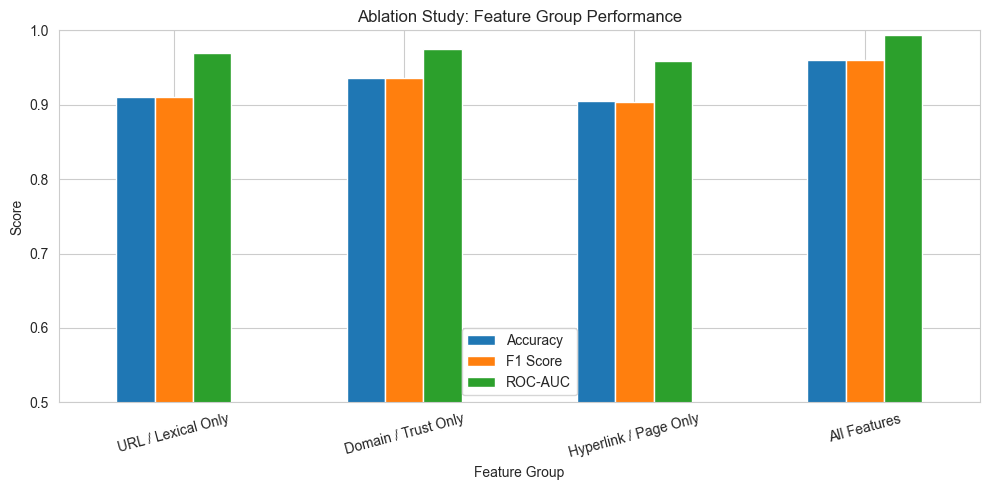

In [7]:
ablation_results.set_index("Feature Group")[["Accuracy", "F1 Score", "ROC-AUC"]].plot(
    kind="bar",
    figsize=(10, 5)
)
plt.title("Ablation Study: Feature Group Performance")
plt.ylabel("Score")
plt.ylim(0.5, 1.0)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()